# 07 — Compléments : compos, joueuses, équipes

Ce notebook regroupe les pistes explorées au-delà des facteurs de match purs, pour avoir tous les chiffres prêts avant la rédaction. Chaque section dit aussi si la piste tient ou non. Même cadre que les notebooks précédents : on réutilise outils.py et on raisonne en différentiel équipe moins adversaire quand c'est pertinent.

Rappel d'une limite : les données sont du box-score par match, sans play-by-play. On étudie donc le cinq de départ (flag Starter), pas les quintets sur le terrain.

In [1]:
import sys
from pathlib import Path
p = Path.cwd()
while not (p / 'analyse' / 'outils.py').exists() and p != p.parent:
    p = p.parent
sys.path.insert(0, str(p / 'analyse'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
import outils as o
OUT = o.RESULTATS / 'complements'; OUT.mkdir(parents=True, exist_ok=True)
pd.set_option('display.width', 140); pd.set_option('display.max_columns', 30)

df  = o.charger_equipes(o.SAISONS_COMPLETES)
t   = o.agreger_equipe_match(df)
L   = o.lire_liste_joueuses()
cal = o.charger_calendrier(forme=False)
j   = df[~df['Joueur'].isin(['TOTAUX EQUIPE', 'Team / Coach'])].copy()
print('equipe-matchs:', len(t), '| joueuses-saisons (liste 11 saisons):', len(L),
      '| matchs calendrier:', len(cal))

equipe-matchs: 438 | joueuses-saisons (liste 11 saisons): 1927 | matchs calendrier: 264


## La taille du cinq de départ

On mesure, pour chaque match, le nombre de titulaires d'au moins 1,85 m, puis on compare à l'adversaire. La question : aligner un cinq plus grand fait-il gagner ?

In [2]:
tail = o.tailles_par_cle()
st = j[j['Starter/bench'] == 'Starter'].merge(tail, on=['cle', 'Saison'], how='left')
m5 = (st.groupby(['eq', 'Saison', 'Num_match'])
      .agg(n_grandes=('taille', lambda s: (s >= 1.85).sum()),
           taille_moy=('taille', 'mean'), n_dispo=('taille', 'count'),
           dom_ext=('dom_ext', 'first'), adv=('adv', 'first')).reset_index())
m5 = m5.merge(t[['eq', 'Saison', 'Num_match', 'Victoire']], on=['eq', 'Saison', 'Num_match'])
m5 = m5[m5['n_dispo'] >= 4]
dd = o.differentiel_adversaire(m5, ['n_grandes', 'taille_moy']).dropna(subset=['d_n_grandes'])
dd['avantage'] = np.sign(dd['d_n_grandes']).map({-1.0: 'moins de grandes', 0.0: 'a egalite', 1.0: 'plus de grandes'})
grp = dd.groupby('avantage')['Victoire'].agg(taux_victoire='mean', n='size').reset_index()
r, pv = pointbiserialr(dd['Victoire'], dd['d_n_grandes'])
grp.to_csv(OUT / 'compo_taille_cinq.csv', index=False)
print('Avantage en titulaires >= 1.85 m sur l adversaire  ->  taux de victoire')
print(grp.round(2).to_string(index=False))
print(f'\ncorrelation d_n_grandes vs victoire : r = {r:.3f}, p = {pv:.4f}')

Avantage en titulaires >= 1.85 m sur l adversaire  ->  taux de victoire
        avantage  taux_victoire  n
       a egalite           0.50 90
moins de grandes           0.32 84
 plus de grandes           0.68 84

correlation d_n_grandes vs victoire : r = 0.291, p = 0.0000


Lecture. L'équipe qui aligne plus de grandes que l'adversaire gagne environ deux fois sur trois, contre une sur trois quand elle en aligne moins. L'effet est net et significatif (p < 0,001). C'est le nombre de grandes qui porte le signal, pas la taille moyenne. Nuance honnête : la taille va souvent avec le budget, donc l'effet n'est pas purement mécanique.

## La courbe d'âge : pic de performance

On relie l'impact (EVAL moyen par saison) à l'âge de la joueuse, sur les joueuses à au moins 200 minutes dans la saison. La question du sujet : le championnat cherche-t-il la jeunesse ou l'expérience ?

Performance (EVAL moyen) par tranche d age
tranche  EVAL_moyen  n
   <=19        6.85 12
  20-21        6.70 14
  22-23        8.98 22
  24-25        9.90 27
  26-27       10.26 28
  28-29       10.94 25
  30-31        8.49 11
    32+        9.59 28

age moyen des joueuses regulieres (>= 200 min) : 26.4 ans
pic de performance estime (parabole) : 29.1 ans


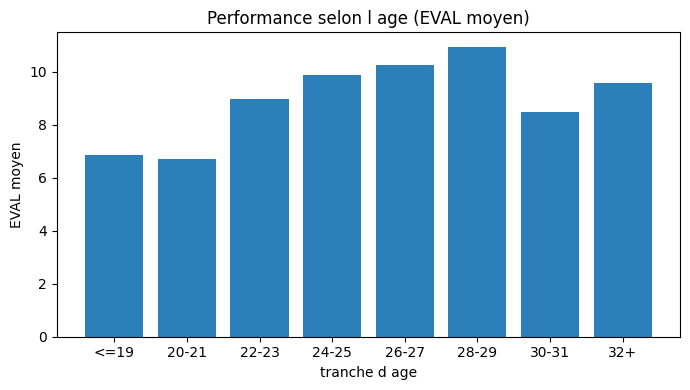

In [3]:
agg = j.groupby(['cle', 'Saison']).agg(EVAL_moy=('EVAL', 'mean'), min_tot=('Tps_jeu_decimal', 'sum')).reset_index()
La = L[['cle', 'Saison', 'age_num']].dropna().drop_duplicates(['cle', 'Saison'])
ma = agg.merge(La, on=['cle', 'Saison']).query('min_tot >= 200')
labels = ['<=19', '20-21', '22-23', '24-25', '26-27', '28-29', '30-31', '32+']
ma['tranche'] = pd.cut(ma['age_num'], [0, 19.5, 21.5, 23.5, 25.5, 27.5, 29.5, 31.5, 99], labels=labels)
age_tab = ma.groupby('tranche', observed=True)['EVAL_moy'].agg(EVAL_moyen='mean', n='size').reset_index()
coef = np.polyfit(ma['age_num'], ma['EVAL_moy'], 2); peak = -coef[1] / (2 * coef[0])
age_tab.to_csv(OUT / 'courbe_age.csv', index=False)
print('Performance (EVAL moyen) par tranche d age')
print(age_tab.round(2).to_string(index=False))
print(f'\nage moyen des joueuses regulieres (>= 200 min) : {ma["age_num"].mean():.1f} ans')
print(f'pic de performance estime (parabole) : {peak:.1f} ans')

plt.figure(figsize=(7, 4))
plt.bar(age_tab['tranche'].astype(str), age_tab['EVAL_moyen'], color='#2c7fb8')
plt.title('Performance selon l age (EVAL moyen)'); plt.xlabel('tranche d age'); plt.ylabel('EVAL moyen')
plt.tight_layout(); plt.savefig(OUT / 'courbe_age.png', dpi=130); plt.show()

Lecture. La performance monte régulièrement de 22 à 29 ans et culmine vers 28-29 ans. Les jeunes de 21 ans et moins sont nettement en dessous, malgré du temps de jeu. La LFB valorise donc l'expérience plus que la jeunesse. Biais à garder en tête : les vétéranes qui restent sont les meilleures, ce qui gonfle un peu la fin de courbe.

## Fidélité au club et turnover des effectifs

Sur les onze saisons de la liste des joueuses, on suit qui reste et qui part. La question du sujet : quels clubs renouvellent le plus leur effectif ?

In [4]:
P = L.dropna(subset=['eq']).drop_duplicates(['cle', 'Saison', 'eq'])
eff = P.groupby(['eq', 'Saison'])['cle'].apply(set)
saisons = sorted(P['Saison'].unique(), key=lambda s: int(s[:2]))
rows = []
for eq in P['eq'].unique():
    for s0, s1 in zip(saisons, saisons[1:]):
        if (eq, s0) in eff.index and (eq, s1) in eff.index and len(eff[(eq, s0)]) > 0:
            a, b = eff[(eq, s0)], eff[(eq, s1)]
            rows.append({'eq': eq, 'turnover': len(a - b) / len(a)})
to = pd.DataFrame(rows)
club = (to.groupby('eq')['turnover'].agg(turnover='mean', n_transitions='size'))
club = club[club['n_transitions'] >= 3].sort_values('turnover')
club['turnover_%'] = (club['turnover'] * 100).round(0)
club[['turnover_%', 'n_transitions']].to_csv(OUT / 'turnover_clubs.csv')
g = P.groupby('cle').agg(n_clubs=('eq', 'nunique'), n_saisons=('Saison', 'nunique'))
multi = g[g['n_saisons'] >= 2]
print(f'turnover moyen de la ligue : {to["turnover"].mean()*100:.0f}% des effectifs renouveles chaque an')
print(f'joueuses presentes au moins 2 saisons : {len(multi)} | fideles a 1 club : {(multi["n_clubs"]==1).mean()*100:.0f}%\n')
print('Clubs du plus stable au plus volatil (au moins 3 transitions) :')
print(club[['turnover_%', 'n_transitions']].to_string())

turnover moyen de la ligue : 60% des effectifs renouveles chaque an
joueuses presentes au moins 2 saisons : 404 | fideles a 1 club : 44%

Clubs du plus stable au plus volatil (au moins 3 transitions) :
                 turnover_%  n_transitions
eq                                        
bourges                50.0             10
mondeville             50.0              3
basket landes          54.0             10
angers                 55.0              5
roche vendee           56.0              8
lyon                   59.0             10
saint-amand            59.0              8
nantes                 61.0              5
tarbes                 62.0              8
villeneuve ascq        63.0             10
landerneau             63.0              7
montpellier            64.0             10
charnay                65.0              4
charleville            66.0             10


Lecture. Le championnat renouvelle environ 60 % de ses effectifs chaque été, et plus de la moitié des joueuses présentes sur plusieurs saisons changent de club. Bourges garde le plus son effectif, Charleville le change le plus. Limite : l'appariement se fait par initiale plus nom, et un départ mêlange transfert et fin de carrière.

## Pépites et joueuses sous-cotées

On agrège par joueuse-saison (au moins 8 matchs) et on regarde le rendement par minute (EVAL/min). Deux questions : sur quelle jeune miser, et quelles role-players rendent beaucoup sur peu de minutes ?

In [5]:
pj = (j.groupby(['cle', 'Saison'])
      .agg(Joueur=('Joueur', lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
           eq=('eq', 'first'), matchs=('Pts', 'size'), min_match=('Tps_jeu_decimal', 'mean'),
           eval_tot=('EVAL', 'sum'), min_tot=('Tps_jeu_decimal', 'sum'), Pts=('Pts', 'sum')).reset_index())
pj['eval_min'] = pj['eval_tot'] / (pj['min_tot'] + 1e-9)
pj = pj.merge(L[['cle', 'Saison', 'age_num']].drop_duplicates(['cle', 'Saison']), on=['cle', 'Saison'], how='left')
pj = pj[pj['matchs'] >= 8]
cols = ['Joueur', 'eq', 'Saison', 'age_num', 'matchs', 'min_match', 'eval_min', 'Pts']
pepites = pj[(pj['age_num'] <= 22) & (pj['min_match'] >= 10)].sort_values('eval_min', ascending=False).head(6)
med = pj['min_match'].median(); seuil = pj['eval_min'].quantile(0.7)
sous = pj[(pj['eval_min'] >= seuil) & (pj['min_match'] >= 10) & (pj['min_match'] <= med)].sort_values('eval_min', ascending=False).head(6)
pepites[cols].to_csv(OUT / 'pepites.csv', index=False); sous[cols].to_csv(OUT / 'sous_cotees.csv', index=False)
print('Jeunes pepites (<= 22 ans, >= 10 min/match), par rendement/minute :')
print(pepites[cols].round(2).to_string(index=False))
print('\nRole-players sous-cotees (fort rendement/min, minutes plafonnees) :')
print(sous[cols].round(2).to_string(index=False))

Jeunes pepites (<= 22 ans, >= 10 min/match), par rendement/minute :
        Joueur              eq Saison  age_num  matchs  min_match  eval_min   Pts
    D. Malonga            lyon  24-25     19.0      22      33.09      0.62 339.0
     J. Salaun villeneuve ascq  23-24     22.0      22      27.67      0.58 320.0
     P. Astier         bourges  23-24     21.0      19      22.72      0.51 181.0
      C. Leite villeneuve ascq  24-25     20.0      21      27.98      0.51 344.0
      G. Rabot     montpellier  23-24     21.0      17      23.29      0.49 103.0
M. Akoa Makani         charnay  23-24     22.0      22      30.12      0.48 276.0

Role-players sous-cotees (fort rendement/min, minutes plafonnees) :
              Joueur            eq Saison  age_num  matchs  min_match  eval_min   Pts
            K. Diaby       bourges  24-25     29.0      21      21.72      0.84 300.0
        K. Alexander       bourges  23-24     32.0      21      22.42      0.84 281.0
D. Fankam Mendjiadeu   montpell

Lecture. D. Malonga (Lyon, 19 ans) ressort comme la pépite : un rendement par minute parmi les meilleurs de la ligue, sur un vrai volume de jeu. Côté sous-cotées, des joueuses comme K. Diaby et K. Alexander (Bourges) rendent beaucoup sur des minutes plafonnées, ce sont des cibles de recrutement intéressantes. Limite : deux saisons seulement, donc pas de trajectoire de progression mesurable.

## Forteresses à domicile

Pour chaque équipe, taux de victoire et marge au score à domicile contre à l'extérieur. Qui est imbattable chez soi, qui voyage bien ?

In [6]:
home = cal.groupby('dom').agg(n_dom=('home_win', 'size'), wr_dom=('home_win', 'mean'), marge_dom=('ecart', 'mean'))
aw = cal.assign(away_win=1 - cal['home_win'], away_marge=-cal['ecart'])
away = aw.groupby('ext').agg(n_ext=('away_win', 'size'), wr_ext=('away_win', 'mean'), marge_ext=('away_marge', 'mean'))
fort = home.join(away)
fort['ecart_dom_ext'] = fort['wr_dom'] - fort['wr_ext']
fort = fort.sort_values('wr_dom', ascending=False)
fort.to_csv(OUT / 'forteresse_domicile.csv')
show = fort.assign(wr_dom=(fort['wr_dom'] * 100).round(0), wr_ext=(fort['wr_ext'] * 100).round(0),
                   ecart_dom_ext=(fort['ecart_dom_ext'] * 100).round(0))
print('Taux de victoire (%) et marge moyenne, domicile vs exterieur')
print(show[['n_dom', 'wr_dom', 'marge_dom', 'wr_ext', 'marge_ext', 'ecart_dom_ext']].round(1).to_string())

Taux de victoire (%) et marge moyenne, domicile vs exterieur
                 n_dom  wr_dom  marge_dom  wr_ext  marge_ext  ecart_dom_ext
dom                                                                        
bourges             22    95.0       16.0    68.0        5.3           27.0
basket landes       22    91.0       13.6    64.0        3.6           27.0
charleville         22    77.0        8.1    50.0        1.1           27.0
montpellier         22    73.0        7.6    55.0        2.5           18.0
charnay             22    64.0        4.3    55.0       -1.5            9.0
lyon                22    59.0        3.5    23.0       -4.5           36.0
landerneau          22    59.0       -0.2    36.0       -7.3           23.0
tarbes              11    55.0        2.2    27.0       -4.8           27.0
angers              22    45.0       -3.5    32.0       -4.2           14.0
villeneuve ascq     22    45.0       -1.0    36.0       -1.8            9.0
roche vendee        22    4

Lecture. Bourges gagne partout, à domicile (95 %) comme à l'extérieur (68 %), marque d'une vraie équipe de tête. Lyon a les deux visages les plus opposés : solide chez elle (59 %), elle s'effondre en déplacement (23 %), soit le plus grand écart de la ligue. Basket Landes et Charleville dépendent aussi nettement de leur salle. Chartres reste faible des deux côtés (23 %). Attention aux équipes à une seule saison de données (Tarbes, Toulouse, n = 11).

## Ce qu'on a testé et qui ne tient pas

Ces résultats négatifs nourrissent la partie recul du rapport. Deux d'entre eux se chiffrent vite et valent d'être montrés : la dépendance à la star et le plus/minus individuel.

In [7]:
# dependance a la star : marqueur de faiblesse, pas de variabilite
es = (t.groupby(['eq', 'Saison']).agg(dep_star=('dep_star', 'mean'), winrate=('Victoire', 'mean'), n=('Victoire', 'size')).reset_index())
es = es[es['n'] >= 5]
r_win = es['dep_star'].corr(es['winrate'])

# +/- confondu par l equipe
pm = j.copy()
pm['pm'] = pd.to_numeric(pm['+/-'].astype(str).str.replace(',', '.', regex=False), errors='coerce')
ps = pm.dropna(subset=['pm']).groupby(['cle', 'Saison', 'eq']).agg(pm=('pm', 'sum')).reset_index()
grand = ps['pm'].mean()
between = (ps.groupby(['eq', 'Saison'])['pm'].transform('mean') - grand) ** 2
eta2 = between.sum() / ((ps['pm'] - grand) ** 2).sum()
print(f'corr(dependance a la star, taux de victoire) = {r_win:.2f}')
print('  -> negatif : compter sur une seule marqueuse accompagne la defaite, ce n est pas un atout')
print(f'part de la variance du +/- portee par l equipe-saison : {eta2*100:.0f}%')
print('  -> le +/- reflete surtout la force du collectif, il ne sert pas a juger une joueuse')

corr(dependance a la star, taux de victoire) = -0.69
  -> negatif : compter sur une seule marqueuse accompagne la defaite, ce n est pas un atout
part de la variance du +/- portee par l equipe-saison : 46%
  -> le +/- reflete surtout la force du collectif, il ne sert pas a juger une joueuse


Bilan des rejets, à réutiliser pour la partie limites du rapport :

- Le style de jeu ne prédit pas la victoire (démontré au notebook 03).
- La stabilité du cinq de départ n'a aucun effet ; c'est la taille qui compte.
- La dépendance à une star est un marqueur de faiblesse, pas une source d'imprévisibilité.
- Le plus/minus individuel est confondu par la force de l'équipe, inutile pour le recrutement.
- Prédire les playoffs est infaisable ici : pas d'ELO en phase finale et saisons décalées.
- Deux intuitions tombent : les étrangères ne jouent pas moins collectif, et les paris ne sont pas rentables (notebooks 02 et 06).

## Fichiers produits

Tout est sauvegardé dans resultats/complements : compo_taille_cinq.csv, courbe_age.csv et courbe_age.png, turnover_clubs.csv, pepites.csv, sous_cotees.csv, forteresse_domicile.csv. Prêt à citer dans le rapport.